# EEG Lab — Notebook 1: first steps in Python & loading the data

**Goal:** learn just enough Python to open the EEG file, look at what it contains and plot the raw signal.

Prerequisite: having run **Notebook 0** (the file `eeg_data.csv` must exist in the same folder).

## 1. Python as a calculator

Everything starts simply. Run the cell (Shift + Enter).

In [1]:
2 + 3 * 4

14

The `print()` function is used to **display** a message. Text between quotes is called a *string*.

In [2]:
print("Hello, neuroscience!")
print("One second contains", 250, "EEG samples.")

Hello, neuroscience!
One second contains 250 EEG samples.


## 2. Variables

A variable holds a value so you can reuse it. Try changing the number of electrodes and re-run.

In [3]:
fs = 250
n_channels = 8
duration = 60   # seconds

n_samples = fs * duration
print("In", duration, "seconds, we record", n_samples, "points per channel.")

In 60 seconds, we record 15000 points per channel.


## 3. Lists

A **list** stores several values in order, between square brackets `[ ]`. You access an element by its position (which **starts at 0**!).

In [4]:
channels = ['Fp1', 'Fp2', 'C3', 'C4', 'O1', 'O2']

print("The first channel is:", channels[0])
print("The third channel is:", channels[2])
print("Number of channels in the list:", len(channels))

The first channel is: Fp1
The third channel is: C3
Number of channels in the list: 6


## 4. Load the EEG file with pandas

We import the tools, then read the CSV into a *DataFrame* (a table).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('eeg_data.csv')
print("File loaded. Dimensions:", df.shape, "(rows, columns)")

File loaded. Dimensions: (15000, 9) (rows, columns)


## 5. Explore the contents

A few essential commands to inspect a table.

In [6]:
df.head()        # the first 5 rows

,Fp1,Fp2,C3,C4,P7,P8,O1,O2,marker
0,0.092000,-14.625484,8.987525,-6.547134,-4.944897,0.148880,-1.327193,4.959388,0.0
1,-7.252779,1.734556,10.285500,13.988153,-2.524806,1.201113,-0.761411,19.605560,0.0
2,5.398207,3.750631,8.400295,1.738137,5.435477,5.992507,2.404634,6.487170,0.0
3,2.183192,0.681534,2.229465,6.066458,-10.590069,6.060448,-3.369264,-1.654360,0.0
4,-22.248449,-9.149569,1.281958,-1.189225,-25.358966,-11.600134,-14.424075,0.147765,0.0


In [7]:
print("Column names:")
print(list(df.columns))

Column names:
['Fp1', 'Fp2', 'C3', 'C4', 'P7', 'P8', 'O1', 'O2', 'marker']


In [8]:
df.describe()    # basic statistics (mean, min, max...) per column

,Fp1,Fp2,C3,C4,P7,P8,O1,O2,marker
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,-0.004870,-0.084515,0.105826,0.054424,-0.091944,-0.141456,-0.035320,-0.047303,0.500000
std,8.794168,8.792204,8.773436,8.753765,12.561989,12.517728,12.486008,12.525434,0.500017
min,-35.718320,-34.440247,-34.104954,-34.917164,-45.747474,-43.501095,-43.610974,-44.534014,0.000000
25%,-5.992174,-6.030740,-5.862162,-5.831767,-8.396401,-8.405023,-8.349702,-8.366940,0.000000
50%,-0.007030,-0.118059,0.109105,0.065573,-0.149077,-0.103512,0.060463,-0.044083,0.500000
75%,5.962529,5.829240,5.962907,5.952653,8.302089,8.095138,8.188133,8.178065,1.000000
max,34.372813,36.459182,33.400727,34.097367,49.671031,41.080655,48.220092,43.976337,1.000000


## 6. Extract a single channel

We select one column by its name. The result is a sequence of values that we convert to a `numpy` array with `.to_numpy()`.

In [9]:
o1 = df['O1'].to_numpy()

print("Type:", type(o1))
print("Number of points:", len(o1))
print("First 5 values:", o1[:5])

Type: <class 'numpy.ndarray'>
Number of points: 15000
First 5 values: [ -1.32719338  -0.761411     2.40463397  -3.36926415 -14.42407529]


## 7. Build the time axis

Each point is spaced `1/fs` seconds apart. `np.arange(n)` creates the sequence `0, 1, 2, ..., n-1`; we divide it by `fs` to get seconds.

In [10]:
fs = 250
n = len(o1)
time = np.arange(n) / fs

print("The last recorded instant:", round(time[-1], 2), "seconds")

The last recorded instant: 60.0 seconds


## 8. Plot the raw signal

Finally, the first curve! We show only the first 5 seconds so it stays readable.

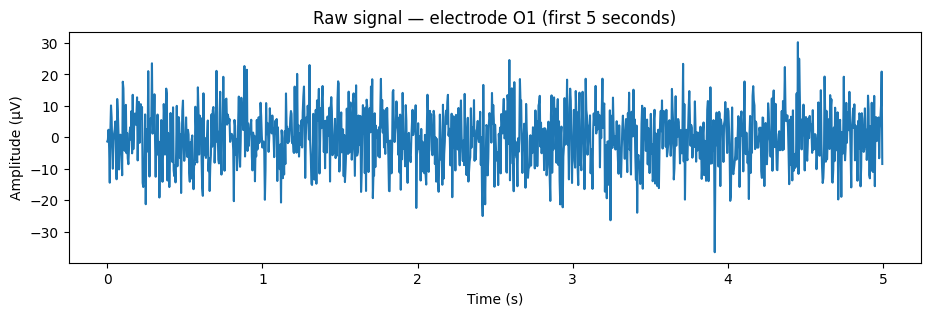

In [11]:
mask = time < 5      # a true/false filter: keep only t < 5 s

plt.figure(figsize=(11, 3))
plt.plot(time[mask], o1[mask])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("Raw signal — electrode O1 (first 5 seconds)")
plt.show()

## 🧠 Your turn

1. Plot the signal of electrode **Fp1** instead of O1.
2. Change the time window to show **from 10 to 15 seconds**.

*Hint: copy the previous cells and change the channel name and the mask condition (e.g. `(time >= 10) & (time < 15)`).*

In [12]:
# Your code here
